In [82]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/fardanhafidz/praktikum-dm-02-train-csv/train.csv')

In [83]:
display(df.head())

print(df.shape)

df.info()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

In [84]:
null_count = df.isnull().sum()

null_percentage = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Jumlah Missing': null_count,
    'Persentase (%)': null_percentage
})

missing_data = missing_data[missing_data['Jumlah Missing'] > 0].sort_values(by='Persentase (%)', ascending=False)

display(missing_data)

,Jumlah Missing,Persentase (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [85]:
threshold = 0.5 * len(df)
cols_to_drop = df.columns[df.isnull().sum() > threshold]
df = df.drop(columns=cols_to_drop)

print("Kolom yang dihapus:", list(cols_to_drop))
df.head()

Kolom yang dihapus: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [86]:
# isi missing val dengan modus dan median
# special case untuk fitur numerik khusus (NaN = tidak ada fasilitas, maka kita set = 0)
zero_fill_cols = ['GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

numeric_cols = df.select_dtypes(include=['number']).columns.drop(['SalePrice'], errors='ignore')
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df[categorical_cols] = df[categorical_cols].fillna('None')

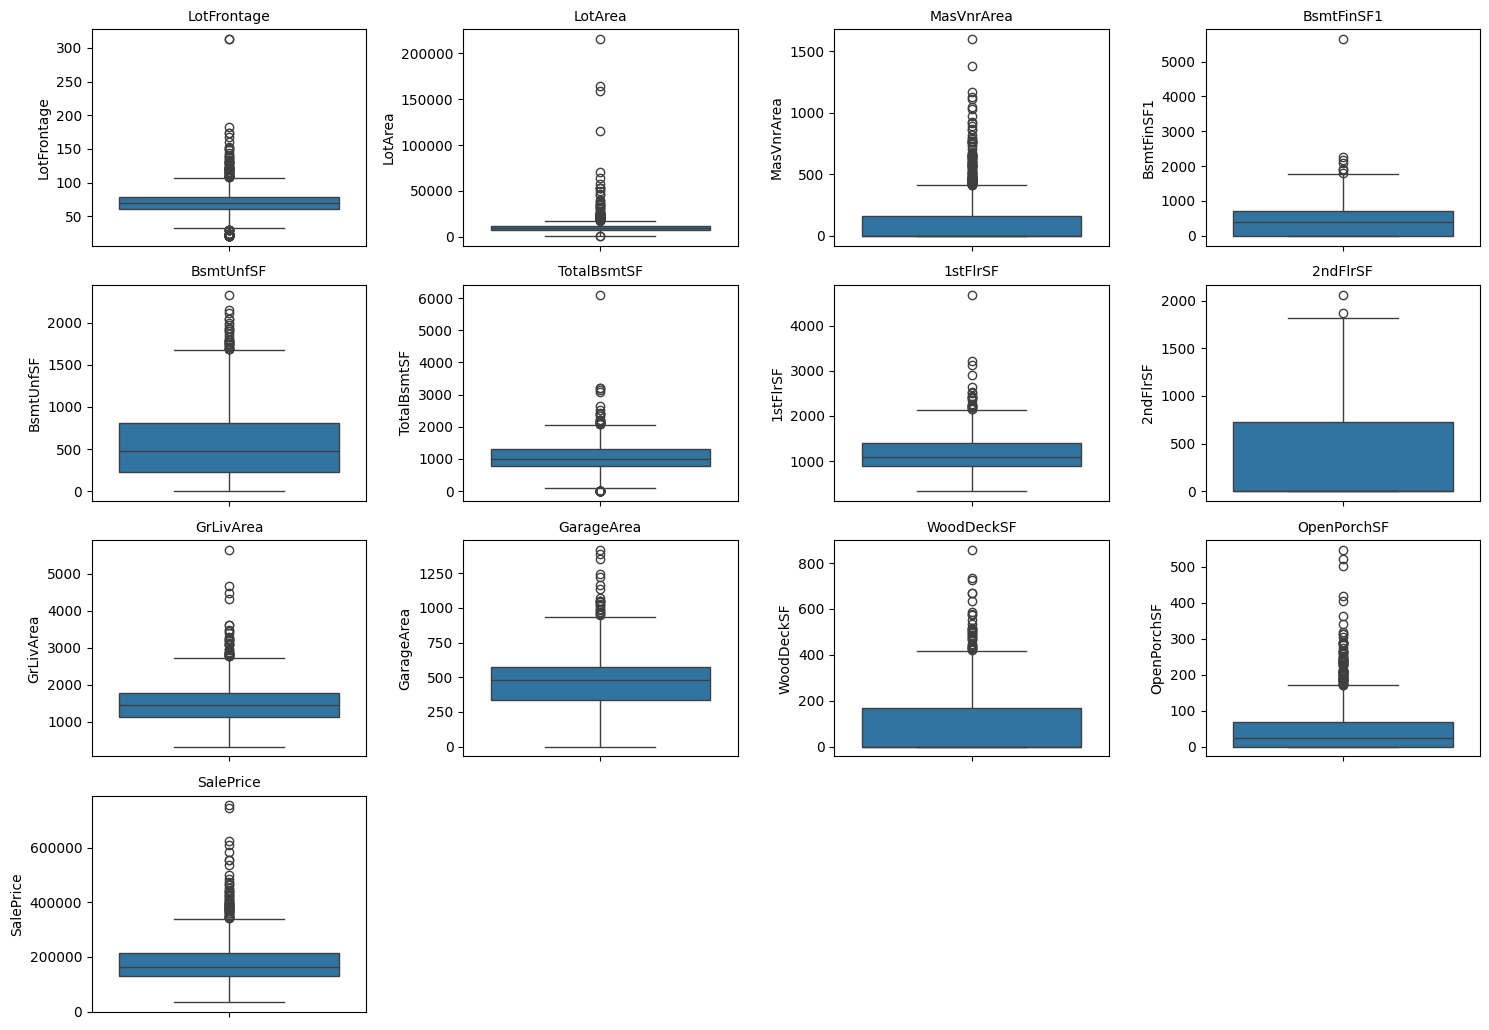

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# cek cuman fitur kontinu
continuous_cols = [
    'LotFrontage',
    'LotArea',
    'MasVnrArea',
    'BsmtFinSF1',
    'BsmtUnfSF',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'GrLivArea',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF',
    'SalePrice'
]

plt.figure(figsize=(15, len(continuous_cols) * 0.8))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(len(continuous_cols) // 4 + 1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.show()

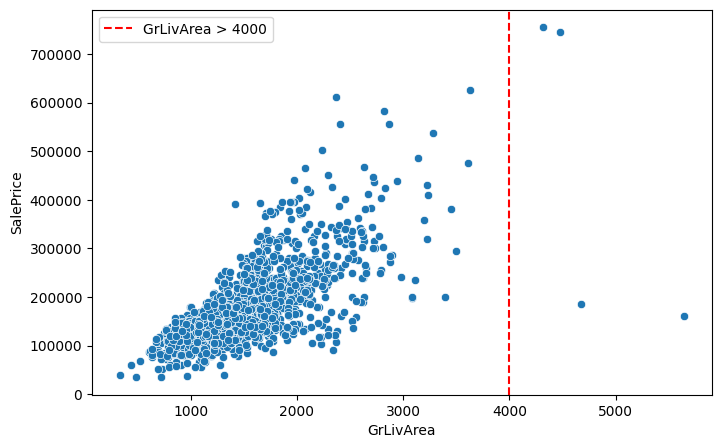

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.axvline(x=4000, color='r', linestyle='--', label='GrLivArea > 4000')
plt.legend()
plt.show()

In [89]:
# drop tanah luas banget but harga murah
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

In [90]:
# membatasi row dengan data jauh di atas batas atas
cap_cols = ['TotalBsmtSF', '1stFlrSF', 'GarageArea']

for col in cap_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    df[col] = df[col].clip(upper=upper_limit)

In [91]:
import numpy as np

# menjaga distribusi harga rumah
df['SalePrice'] = np.log1p(df['SalePrice'])

In [92]:
# encoding kolom kategorikal
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = [col for col in numeric_cols if col not in ['SalePrice', 'Id']]
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

df_encoded[cols_to_scale].describe().round(2).loc[['mean', 'std']]

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
mean,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,...,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [94]:
X = df_encoded.drop(columns=['SalePrice', 'Id'], errors='ignore')
y = df_encoded['SalePrice']

corr_matrix = X.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.80)]
print("Fitur yang memiliki korelasi > 0.80 dengan fitur lain:")
print(high_corr_cols)

Fitur yang memiliki korelasi > 0.80 dengan fitur lain:
['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea', 'MSZoning_RM', 'Neighborhood_Somerst', 'HouseStyle_2Story', 'RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'ExterQual_TA', 'ExterCond_TA', 'BsmtQual_None', 'BsmtCond_None', 'BsmtExposure_None', 'BsmtFinType1_None', 'BsmtFinType2_None', 'KitchenQual_TA', 'FireplaceQu_None', 'GarageType_None', 'GarageFinish_None', 'GarageQual_None', 'GarageCond_None', 'SaleCondition_Partial']


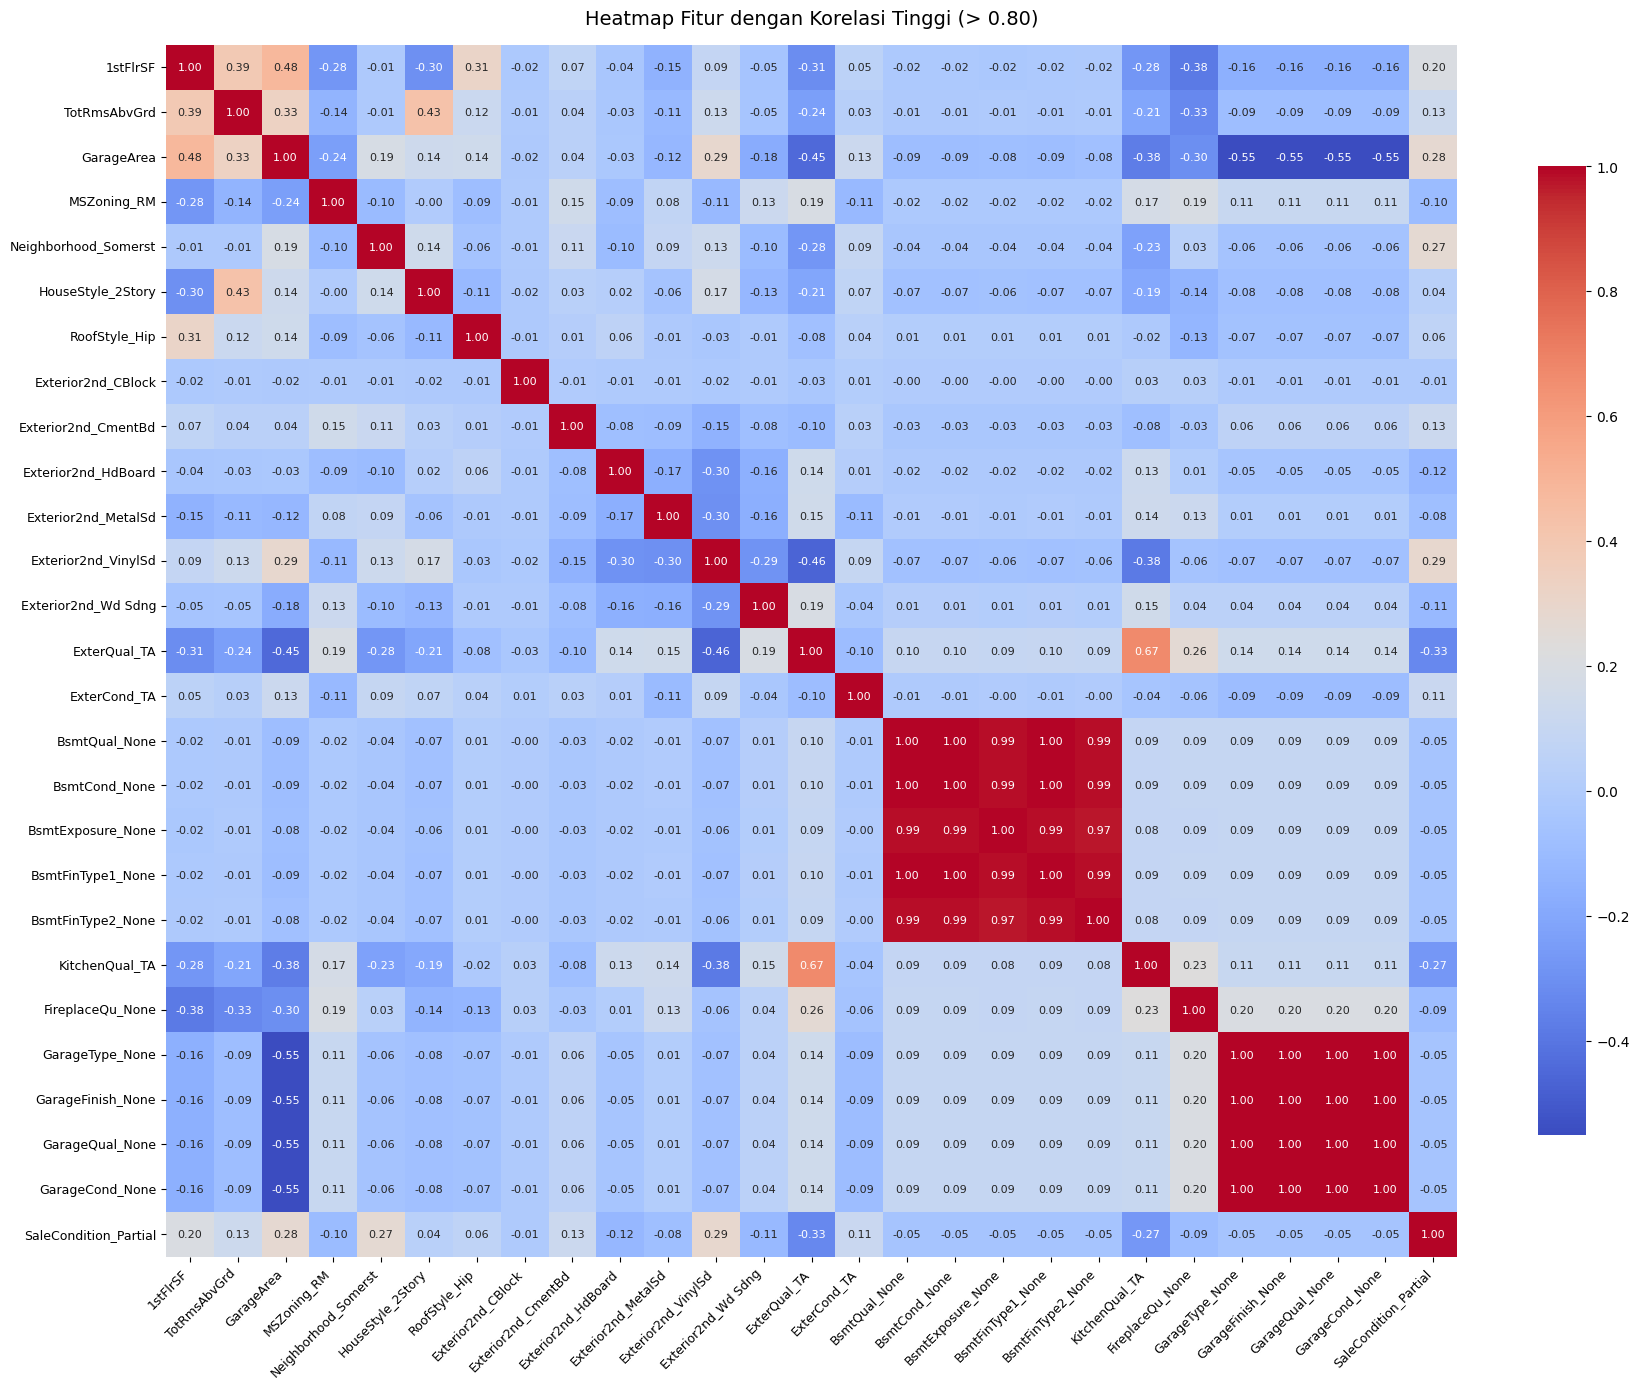

In [95]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    X[high_corr_cols].corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    annot_kws={"size": 8},
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title("Heatmap Fitur dengan Korelasi Tinggi (> 0.80)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [96]:
# Drop fitur-fitur redundan dari dataframe prediktor
X_reduced = X.drop(columns=high_corr_cols)

print("Jumlah fitur sebelum reduksi korelasi:", X.shape[1])
print("Jumlah fitur setelah reduksi korelasi:", X_reduced.shape[1])

Jumlah fitur sebelum reduksi korelasi: 243
Jumlah fitur setelah reduksi korelasi: 216


In [97]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_reduced)

print("Jumlah fitur awal:", X_reduced.shape[1])
print("Jumlah komponen hasil PCA:", X_pca.shape[1])

Jumlah fitur awal: 216
Jumlah komponen hasil PCA: 43


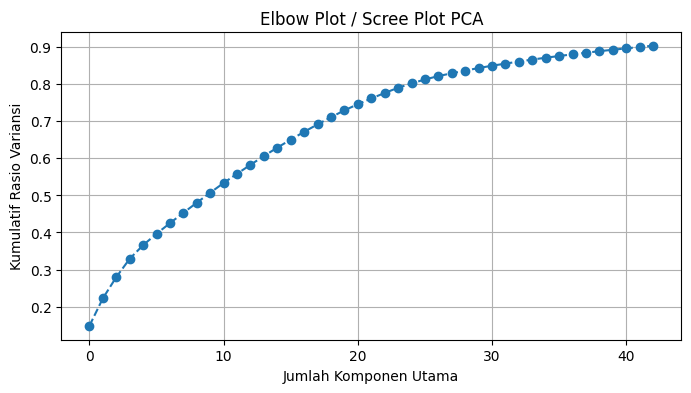

In [98]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Kumulatif Rasio Variansi')
plt.title('Elbow Plot / Scree Plot PCA')
plt.grid(True)
plt.show()

In [99]:
cols_to_drop_corr = [
    '1stFlrSF',
    'TotRmsAbvGrd',
    'GarageArea',
    'Exterior2nd_CBlock',
    'Exterior2nd_CmentBd',
    'Exterior2nd_HdBoard',
    'Exterior2nd_MetalSd',
    'Exterior2nd_VinylSd',
    'Exterior2nd_Wd Sdng'
]

cols_to_drop_corr = [col for col in cols_to_drop_corr if col in X.columns]
X_filtered = X.drop(columns=cols_to_drop_corr)

print(X.shape[1])
print(X_filtered.shape[1])

243
234


133
0.9024647023910319


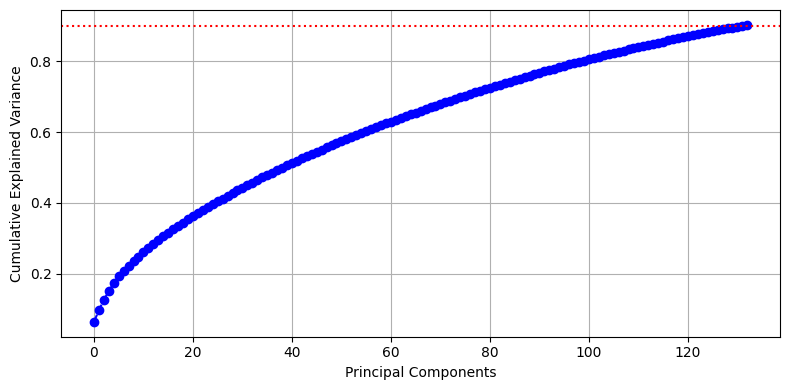

In [100]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pca = StandardScaler()
X_scaled_all = scaler_pca.fit_transform(X_filtered)

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled_all)

print(X_pca.shape[1])
print(pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel('Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle=':')
plt.tight_layout()
plt.show()

In [102]:
pca_columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
df_final = pd.DataFrame(data=X_pca, columns=pca_columns, index=df_encoded.index)

df_final['SalePrice'] = y

# simpan ke file CSV
df_final.to_csv('processed_data.csv', index=False)
print('saksesss')

saksesss
